In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve


In [20]:
# 프로젝트 경로 설정
PROJECT_DIR = Path.cwd().resolve().parent
DATA_SPLIT_DIR = PROJECT_DIR / "processed" / "data_split"
MODELING_OUTPUT_DIR = PROJECT_DIR / "outputs" / "modeling"
WITHIN_OUTPUT_DIR = MODELING_OUTPUT_DIR / "within_t_plus_2"
FIGURE_DIR = MODELING_OUTPUT_DIR / "figures"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_SPLIT_DIR:", DATA_SPLIT_DIR)
print("MODELING_OUTPUT_DIR:", MODELING_OUTPUT_DIR)
print("WITHIN_OUTPUT_DIR:", WITHIN_OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson
DATA_SPLIT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/processed/data_split
MODELING_OUTPUT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling
WITHIN_OUTPUT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling/within_t_plus_2
FIGURE_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling/figures


In [21]:
# 분석 설정값
THRESHOLD = 0.5
MODEL_PROB_COLUMNS = {
    "LR": "lr_prob",
    "RF": "rf_prob",
    "XGB": "xgb_prob",
    "LightGBM": "lgbm_prob",
    "MLP": "mlp_prob",
    "Single-output LSTM": "lstm_prob",
}
HORIZONS = ["y_t", "y_t_plus_1", "y_t_plus_2"]


## Load modeling outputs

In [22]:
# 산출물 로딩
binned = pd.read_csv(DATA_SPLIT_DIR / "events_12h_binned_with_split.csv")
within_summary = pd.read_csv(WITHIN_OUTPUT_DIR / "within_t_plus_2_test_metrics_summary.csv")
within_predictions = pd.read_csv(WITHIN_OUTPUT_DIR / "within_t_plus_2_test_predictions_all_models.csv")

multi_summary = pd.read_csv(MODELING_OUTPUT_DIR / "multi_horizon_test_metrics_summary.csv")
xgb_multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_predictions.csv")
mlp_multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_predictions.csv")
multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_predictions.csv")

xgb_multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_metrics_by_horizon.csv")
mlp_multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_metrics_by_horizon.csv")
multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_metrics_by_horizon.csv")
multi_test_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_metrics.csv")

print("within_predictions", within_predictions.shape)
print("xgb_multi_predictions", xgb_multi_predictions.shape)
print("mlp_multi_predictions", mlp_multi_predictions.shape)
print("multi_predictions", multi_predictions.shape)
display(within_summary)
display(multi_summary)


within_predictions (1590, 33)
xgb_multi_predictions (1944, 33)
mlp_multi_predictions (1944, 33)
multi_predictions (1944, 33)


,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn,...,min_child_samples,optuna_best_trial_number,final_epochs,device,hidden_size,num_layers,dropout,lr,batch_size,weight_decay
0,0.790349,0.710645,0.822866,0.566563,0.548872,0.833080,511,420,549,110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.788719,0.707932,0.763285,0.662539,0.591760,0.813688,474,327,642,147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.782810,0.702035,0.811594,0.602683,0.566929,0.833096,504,385,584,117,...,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.763997,0.696740,0.726248,0.669763,0.584955,0.792430,451,320,649,170,...,NaN,6.0,10.0,NaN,128.0,1.0,0.099358,0.000102,32.0,0.000206
4,0.764855,0.669826,0.731079,0.691434,0.602922,0.800478,454,299,670,167,...,NaN,10.0,10.0,cuda,64.0,3.0,0.348059,0.001931,64.0,0.000009
5,0.754095,0.667539,0.784219,0.543860,0.524220,0.797277,487,442,527,134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,macro_auroc,macro_auprc,within_t_plus_1_auroc,within_t_plus_1_auprc,within_t_plus_1_sensitivity,within_t_plus_1_specificity,within_t_plus_1_ppv,within_t_plus_1_npv,within_t_plus_1_tp,within_t_plus_1_fp,...,reg_alpha,reg_lambda,final_epochs,device,hidden_size,num_layers,dropout,lr,batch_size,weight_decay
0,0.775446,0.473885,0.823930,0.642905,0.964029,0.327089,0.364626,0.957806,536,934,...,0.042648,0.026731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.759904,0.442518,0.792407,0.592986,0.875899,0.506484,0.415529,0.910622,487,685,...,NaN,NaN,24.0,cuda,64.0,1.0,0.194339,0.000252,32.0,0.000042
2,0.761623,0.449113,0.792909,0.586182,0.769784,0.682997,0.493088,0.881041,428,440,...,NaN,NaN,4.0,NaN,256.0,2.0,0.307260,0.000469,32.0,0.000179


In [23]:
# binned modeling table의 anchor bin 기준 이전 delirium feature 결합
anchor_prev_delirium = (
    binned[["stay_id", "bin", "prev_delirium"]]
    .rename(columns={"bin": "anchor_bin"})
)


def attach_prev_delirium_group(prediction_df: pd.DataFrame) -> pd.DataFrame:
    prediction_df = prediction_df.merge(anchor_prev_delirium, on=["stay_id", "anchor_bin"], how="left")
    prediction_df["prev_delirium_group"] = np.where(
        prediction_df["prev_delirium"].astype(float) >= 0.5,
        "prev_delirium",
        "no_prev_delirium",
    )
    return prediction_df

within_predictions = attach_prev_delirium_group(within_predictions)
xgb_multi_predictions = attach_prev_delirium_group(xgb_multi_predictions)
mlp_multi_predictions = attach_prev_delirium_group(mlp_multi_predictions)
multi_predictions = attach_prev_delirium_group(multi_predictions)

prediction_sets = [
    ("within_t_plus_2_full_window_test", within_predictions),
    ("xgb_multi_horizon_test", xgb_multi_predictions),
    ("mlp_multi_horizon_test", mlp_multi_predictions),
    ("lstm_multi_horizon_test", multi_predictions),
]

prev_delirium_summary = pd.DataFrame(
    [
        {
            "dataset": dataset,
            "prev_delirium_group": group,
            "n": len(group_df),
            "within_t_plus_2_positive_rate": group_df["y_within_t_plus_2_true"].mean(),
        }
        for dataset, prediction_df in prediction_sets
        for group, group_df in prediction_df.groupby("prev_delirium_group")
    ]
)

display(prev_delirium_summary)


,dataset,t_minus_1_group,n,within_t_plus_2_positive_rate
0,within_t_plus_2_full_window_test,no_prior_delirium,1227,0.283619
1,within_t_plus_2_full_window_test,prior_delirium,363,0.752066
2,xgb_multi_horizon_test,no_prior_delirium,1539,0.241715
3,xgb_multi_horizon_test,prior_delirium,405,0.703704
4,mlp_multi_horizon_test,no_prior_delirium,1539,0.241715
5,mlp_multi_horizon_test,prior_delirium,405,0.703704
6,lstm_multi_horizon_test,no_prior_delirium,1539,0.241715
7,lstm_multi_horizon_test,prior_delirium,405,0.703704


## Metric functions

In [24]:
def binary_metric_dict(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = THRESHOLD) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "auroc": np.nan,
            "auprc": np.nan,
            "sensitivity": np.nan,
            "specificity": np.nan,
            "ppv": np.nan,
            "npv": np.nan,
            "tp": 0,
            "fp": 0,
            "tn": 0,
            "fn": 0,
        }

    if len(np.unique(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
    else:
        auroc = np.nan
        auprc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)),
        "positive_rate": float(y_true.mean()),
        "auroc": auroc,
        "auprc": auprc,
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "ppv": tp / (tp + fp) if (tp + fp) else np.nan,
        "npv": tn / (tn + fn) if (tn + fn) else np.nan,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def add_metric_row(rows: list[dict], analysis: str, model: str, group: str, target: str, y_true, y_prob):
    row = {
        "analysis": analysis,
        "model": model,
        "prev_delirium_group": group,
        "target": target,
        **binary_metric_dict(y_true, y_prob),
    }
    rows.append(row)


In [ ]:
# 첫 3개 12h bin 제외 후 성능 비교: 36~48시간 시점(anchor_bin >= 4)부터 평가
EVALUATION_START_ANCHOR_BIN = 4
EVALUATION_START_LABEL = "from_36_48h_anchor_bin_ge_4"


def evaluate_within_models(prediction_df: pd.DataFrame, scope: str) -> pd.DataFrame:
    rows = []
    for model, prob_col in MODEL_PROB_COLUMNS.items():
        add_metric_row(
            rows,
            analysis=scope,
            model=model,
            group="all",
            target="within_t_plus_2_delirium",
            y_true=prediction_df["y_within_t_plus_2_true"],
            y_prob=prediction_df[prob_col],
        )
    return pd.DataFrame(rows)


def evaluate_multi_horizon_within_models(prediction_sets: list[tuple[str, pd.DataFrame]], scope: str) -> pd.DataFrame:
    rows = []
    for model, prediction_df in prediction_sets:
        add_metric_row(
            rows,
            analysis=scope,
            model=model,
            group="all",
            target="within_t_plus_2_delirium_from_horizons",
            y_true=prediction_df["y_within_t_plus_2_true"],
            y_prob=prediction_df["y_within_t_plus_2_prob_from_horizons"],
        )
    return pd.DataFrame(rows)


def evaluate_multi_horizon_by_horizon(prediction_sets: list[tuple[str, pd.DataFrame]], scope: str) -> pd.DataFrame:
    rows = []
    for model, prediction_df in prediction_sets:
        for horizon in HORIZONS:
            true_col = f"{horizon}_true"
            prob_col = f"{horizon}_prob"
            mask_col = f"{horizon}_mask"
            subset = prediction_df[prediction_df[mask_col].eq(1)]
            add_metric_row(
                rows,
                analysis=scope,
                model=model,
                group="all",
                target=f"{horizon}_delirium",
                y_true=subset[true_col],
                y_prob=subset[prob_col],
            )
    return pd.DataFrame(rows)


multi_model_prediction_sets = [
    ("XGB independent horizons", xgb_multi_predictions),
    ("MLP multi-output", mlp_multi_predictions),
    ("LSTM encoder-decoder", multi_predictions),
]

within_late_predictions = within_predictions[within_predictions["anchor_bin"].ge(EVALUATION_START_ANCHOR_BIN)].copy()
xgb_multi_late_predictions = xgb_multi_predictions[xgb_multi_predictions["anchor_bin"].ge(EVALUATION_START_ANCHOR_BIN)].copy()
mlp_multi_late_predictions = mlp_multi_predictions[mlp_multi_predictions["anchor_bin"].ge(EVALUATION_START_ANCHOR_BIN)].copy()
lstm_multi_late_predictions = multi_predictions[multi_predictions["anchor_bin"].ge(EVALUATION_START_ANCHOR_BIN)].copy()
multi_late_prediction_sets = [
    ("XGB independent horizons", xgb_multi_late_predictions),
    ("MLP multi-output", mlp_multi_late_predictions),
    ("LSTM encoder-decoder", lstm_multi_late_predictions),
]

late_eval_counts = pd.DataFrame(
    [
        {"dataset": "within_t_plus_2", "scope": "all_test", "n": len(within_predictions), "positive_rate": within_predictions["y_within_t_plus_2_true"].mean()},
        {"dataset": "within_t_plus_2", "scope": EVALUATION_START_LABEL, "n": len(within_late_predictions), "positive_rate": within_late_predictions["y_within_t_plus_2_true"].mean()},
        {"dataset": "multi_horizon", "scope": "all_test", "n": len(xgb_multi_predictions), "positive_rate": xgb_multi_predictions["y_within_t_plus_2_true"].mean()},
        {"dataset": "multi_horizon", "scope": EVALUATION_START_LABEL, "n": len(xgb_multi_late_predictions), "positive_rate": xgb_multi_late_predictions["y_within_t_plus_2_true"].mean()},
    ]
)

within_late_metrics = pd.concat(
    [
        evaluate_within_models(within_predictions, "all_test"),
        evaluate_within_models(within_late_predictions, EVALUATION_START_LABEL),
    ],
    ignore_index=True,
)

multi_late_within_metrics = pd.concat(
    [
        evaluate_multi_horizon_within_models(multi_model_prediction_sets, "all_test"),
        evaluate_multi_horizon_within_models(multi_late_prediction_sets, EVALUATION_START_LABEL),
    ],
    ignore_index=True,
)

multi_late_horizon_metrics = pd.concat(
    [
        evaluate_multi_horizon_by_horizon(multi_model_prediction_sets, "all_test"),
        evaluate_multi_horizon_by_horizon(multi_late_prediction_sets, EVALUATION_START_LABEL),
    ],
    ignore_index=True,
)

within_late_metrics.to_csv(MODELING_OUTPUT_DIR / "within_t_plus_2_late_eval_metrics.csv", index=False)
multi_late_within_metrics.to_csv(MODELING_OUTPUT_DIR / "multi_horizon_late_eval_within_t_plus_2_metrics.csv", index=False)
multi_late_horizon_metrics.to_csv(MODELING_OUTPUT_DIR / "multi_horizon_late_eval_horizon_metrics.csv", index=False)
late_eval_counts.to_csv(MODELING_OUTPUT_DIR / "late_eval_counts.csv", index=False)

print("=== Late evaluation subset: first 3 bins excluded ===")
print(f"Start condition: anchor_bin >= {EVALUATION_START_ANCHOR_BIN} (36~48h bin onward)")
display(late_eval_counts)
display(within_late_metrics.sort_values(["analysis", "auprc"], ascending=[True, False]))
display(multi_late_within_metrics.sort_values(["analysis", "auprc"], ascending=[True, False]))
display(multi_late_horizon_metrics.sort_values(["analysis", "target", "auprc"], ascending=[True, True, False]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metric in zip(axes, ["auroc", "auprc"]):
    plot_df = within_late_metrics.pivot(index="model", columns="analysis", values=metric).sort_values(EVALUATION_START_LABEL, ascending=False)
    plot_df[["all_test", EVALUATION_START_LABEL]].plot(kind="bar", ax=ax, width=0.75)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Within t+2 {metric.upper()}: all vs >=36~48h")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(["All test", ">=36~48h"], frameon=False)
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "within_t_plus_2_all_vs_late_eval_auroc_auprc.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, metric in zip(axes, ["auroc", "auprc"]):
    plot_df = multi_late_within_metrics.pivot(index="model", columns="analysis", values=metric).sort_values(EVALUATION_START_LABEL, ascending=False)
    plot_df[["all_test", EVALUATION_START_LABEL]].plot(kind="bar", ax=ax, width=0.75)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Multi-horizon within t+2 {metric.upper()}: all vs >=36~48h")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(["All test", ">=36~48h"], frameon=False)
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "multi_horizon_within_t_plus_2_all_vs_late_eval_auroc_auprc.png", dpi=200, bbox_inches="tight")
plt.show()

for metric in ["auroc", "auprc"]:
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4), sharey=True)
    for ax, horizon in zip(axes, HORIZONS):
        subset = multi_late_horizon_metrics[multi_late_horizon_metrics["target"].eq(f"{horizon}_delirium")]
        plot_df = subset.pivot(index="model", columns="analysis", values=metric).sort_values(EVALUATION_START_LABEL, ascending=False)
        plot_df[["all_test", EVALUATION_START_LABEL]].plot(kind="bar", ax=ax, width=0.75)
        ax.set_xlabel("Model")
        ax.set_ylabel(metric.upper())
        ax.set_title(horizon.replace("y_", "").replace("_plus_", "+"))
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(["All test", ">=36~48h"], frameon=False)
        ax.tick_params(axis="x", rotation=35)
    fig.suptitle(f"Multi-horizon horizon-specific {metric.upper()}: all vs >=36~48h", y=1.03)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"multi_horizon_horizon_all_vs_late_eval_{metric}.png", dpi=200, bbox_inches="tight")
    plt.show()



## Overall result visualization

In [ ]:
# Within t+2 모델별 기본 AUROC / AUPRC curve 시각화
def plot_roc_pr_curves(prediction_df: pd.DataFrame, target_col: str, model_prob_columns: dict[str, str], title_prefix: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    y_true_all = prediction_df[target_col].astype(int)
    prevalence = y_true_all.mean()

    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Chance")
    axes[1].axhline(prevalence, linestyle="--", color="gray", linewidth=1, label=f"Prevalence = {prevalence:.3f}")

    for model, prob_col in model_prob_columns.items():
        curve_df = prediction_df[[target_col, prob_col]].dropna()
        if curve_df[target_col].nunique() < 2:
            continue

        y_true = curve_df[target_col].astype(int)
        y_prob = curve_df[prob_col].astype(float)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)

        axes[0].plot(fpr, tpr, linewidth=2, label=f"{model} (AUROC {auroc:.3f})")
        axes[1].plot(recall, precision, linewidth=2, label=f"{model} (AUPRC {auprc:.3f})")

    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{title_prefix}: ROC curve")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)
    axes[0].legend(frameon=False, fontsize=9)

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix}: Precision-Recall curve")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend(frameon=False, fontsize=9)

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_roc_pr_curves(
    within_predictions,
    target_col="y_within_t_plus_2_true",
    model_prob_columns=MODEL_PROB_COLUMNS,
    title_prefix="Within t+2 test",
    output_path=FIGURE_DIR / "within_t_plus_2_test_roc_pr_curves_by_model.png",
)



,model,auprc,auroc,sensitivity,specificity,ppv,npv
0,XGB,0.710645,0.790349,0.822866,0.566563,0.548872,0.833080
1,RF,0.707932,0.788719,0.763285,0.662539,0.591760,0.813688
2,LGBM,0.702035,0.782810,0.811594,0.602683,0.566929,0.833096
3,LSTM,0.696740,0.763997,0.726248,0.669763,0.584955,0.792430
4,MLP,0.669826,0.764855,0.731079,0.691434,0.602922,0.800478
5,LR,0.667539,0.754095,0.784219,0.543860,0.524220,0.797277


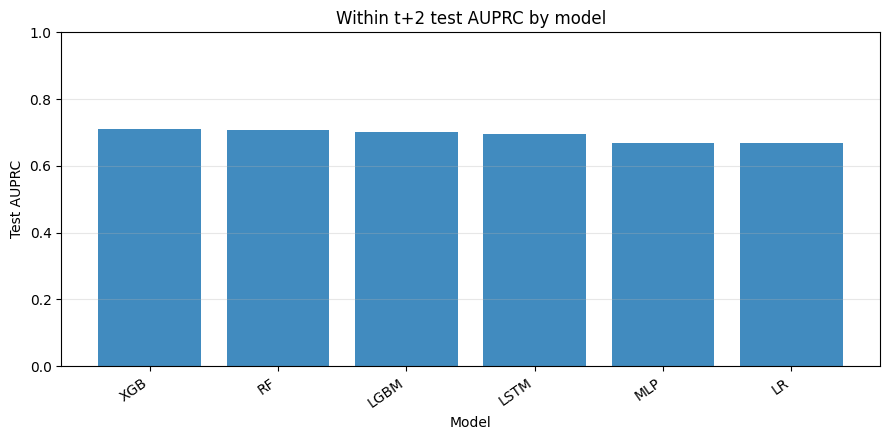

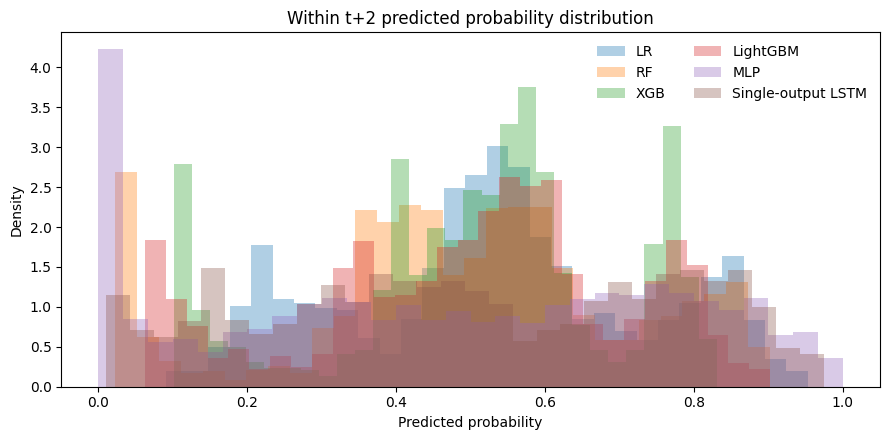

In [26]:
# Within t+2 모델별 test metric 시각화
plot_metric_cols = ["auprc", "auroc", "sensitivity", "specificity", "ppv", "npv"]
within_plot = within_summary[["model", *plot_metric_cols]].copy()
within_plot = within_plot.sort_values("auprc", ascending=False)

display(within_plot)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(within_plot["model"], within_plot["auprc"], color="tab:blue", alpha=0.85)
ax.set_xlabel("Model")
ax.set_ylabel("Test AUPRC")
ax.set_title("Within t+2 test AUPRC by model")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "within_t_plus_2_test_auprc_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for model, prob_col in MODEL_PROB_COLUMNS.items():
    ax.hist(within_predictions[prob_col], bins=30, alpha=0.35, density=True, label=model)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title("Within t+2 predicted probability distribution")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "within_t_plus_2_probability_distribution_by_model.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Multi-horizon 모델별 기본 AUROC / AUPRC curve 시각화
multi_model_prediction_sets = [
    ("XGB independent horizons", xgb_multi_predictions),
    ("MLP multi-output", mlp_multi_predictions),
    ("LSTM encoder-decoder", multi_predictions),
]

multi_within_curve_df = pd.DataFrame(
    {
        "y_within_t_plus_2_true": xgb_multi_predictions["y_within_t_plus_2_true"].astype(int),
        "xgb_prob": xgb_multi_predictions["y_within_t_plus_2_prob_from_horizons"],
        "mlp_prob": mlp_multi_predictions["y_within_t_plus_2_prob_from_horizons"],
        "lstm_prob": multi_predictions["y_within_t_plus_2_prob_from_horizons"],
    }
)

plot_roc_pr_curves(
    multi_within_curve_df,
    target_col="y_within_t_plus_2_true",
    model_prob_columns={
        "XGB independent horizons": "xgb_prob",
        "MLP multi-output": "mlp_prob",
        "LSTM encoder-decoder": "lstm_prob",
    },
    title_prefix="Multi-horizon within t+2 test",
    output_path=FIGURE_DIR / "multi_horizon_within_t_plus_2_roc_pr_curves_by_model.png",
)


def plot_multi_horizon_roc_pr_by_horizon(prediction_sets: list[tuple[str, pd.DataFrame]], horizons: list[str], output_path: Path):
    fig, axes = plt.subplots(len(horizons), 2, figsize=(12, 4.2 * len(horizons)))
    if len(horizons) == 1:
        axes = np.array([axes])

    for row_idx, horizon in enumerate(horizons):
        true_col = f"{horizon}_true"
        prob_col = f"{horizon}_prob"
        mask_col = f"{horizon}_mask"
        roc_ax, pr_ax = axes[row_idx]

        roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Chance")

        prevalence_values = []
        for model, prediction_df in prediction_sets:
            curve_df = prediction_df.loc[prediction_df[mask_col].eq(1), [true_col, prob_col]].dropna()
            if curve_df[true_col].nunique() < 2:
                continue

            y_true = curve_df[true_col].astype(int)
            y_prob = curve_df[prob_col].astype(float)
            prevalence_values.append(y_true.mean())

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            auroc = roc_auc_score(y_true, y_prob)
            auprc = average_precision_score(y_true, y_prob)

            roc_ax.plot(fpr, tpr, linewidth=2, label=f"{model} (AUROC {auroc:.3f})")
            pr_ax.plot(recall, precision, linewidth=2, label=f"{model} (AUPRC {auprc:.3f})")

        if prevalence_values:
            pr_ax.axhline(np.mean(prevalence_values), linestyle="--", color="gray", linewidth=1, label=f"Prevalence = {np.mean(prevalence_values):.3f}")

        horizon_label = horizon.replace("y_", "").replace("_plus_", "+")
        roc_ax.set_title(f"{horizon_label}: ROC curve")
        roc_ax.set_xlabel("False positive rate")
        roc_ax.set_ylabel("True positive rate")
        roc_ax.set_xlim(0, 1)
        roc_ax.set_ylim(0, 1)
        roc_ax.grid(alpha=0.3)
        roc_ax.legend(frameon=False, fontsize=8)

        pr_ax.set_title(f"{horizon_label}: Precision-Recall curve")
        pr_ax.set_xlabel("Recall")
        pr_ax.set_ylabel("Precision")
        pr_ax.set_xlim(0, 1)
        pr_ax.set_ylim(0, 1)
        pr_ax.grid(alpha=0.3)
        pr_ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_multi_horizon_roc_pr_by_horizon(
    multi_model_prediction_sets,
    HORIZONS,
    output_path=FIGURE_DIR / "multi_horizon_test_horizon_roc_pr_curves_by_model.png",
)



,macro_auroc,macro_auprc,within_t_plus_1_auroc,within_t_plus_1_auprc,within_t_plus_1_sensitivity,within_t_plus_1_specificity,within_t_plus_1_ppv,within_t_plus_1_npv,within_t_plus_1_tp,within_t_plus_1_fp,...,reg_alpha,reg_lambda,final_epochs,device,hidden_size,num_layers,dropout,lr,batch_size,weight_decay
0,0.775446,0.473885,0.823930,0.642905,0.964029,0.327089,0.364626,0.957806,536,934,...,0.042648,0.026731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.759904,0.442518,0.792407,0.592986,0.875899,0.506484,0.415529,0.910622,487,685,...,NaN,NaN,24.0,cuda,64.0,1.0,0.194339,0.000252,32.0,0.000042
2,0.761623,0.449113,0.792909,0.586182,0.769784,0.682997,0.493088,0.881041,428,440,...,NaN,NaN,4.0,NaN,256.0,2.0,0.307260,0.000469,32.0,0.000179


,model,split,horizon,n_evaluable,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn
0,XGB independent horizons,test,y_t,1944,0.829710,0.506760,0.884514,0.626360,0.365907,0.956989,337,584,979,44
1,XGB independent horizons,test,y_t_plus_1,1767,0.765377,0.478107,0.744318,0.657244,0.350736,0.911765,262,485,930,90
2,XGB independent horizons,test,y_t_plus_2,1590,0.731250,0.436787,0.756839,0.561459,0.310474,0.898477,249,553,708,80
3,MLP multi-output,test,y_t,1944,0.787136,0.466552,0.700787,0.725528,0.383621,0.908654,267,429,1134,114
4,MLP multi-output,test,y_t_plus_1,1767,0.755688,0.448389,0.676136,0.711661,0.368421,0.898305,238,408,1007,114
5,MLP multi-output,test,y_t_plus_2,1590,0.736888,0.412612,0.720365,0.656622,0.353731,0.900000,237,433,828,92
6,LSTM encoder-decoder,test,y_t,1944,0.787899,0.469047,0.706037,0.724248,0.384286,0.909968,269,431,1132,112
7,LSTM encoder-decoder,test,y_t_plus_1,1767,0.761303,0.448416,0.661932,0.725795,0.375201,0.896161,233,388,1027,119
8,LSTM encoder-decoder,test,y_t_plus_2,1590,0.735667,0.429877,0.656535,0.693894,0.358804,0.885628,216,386,875,113


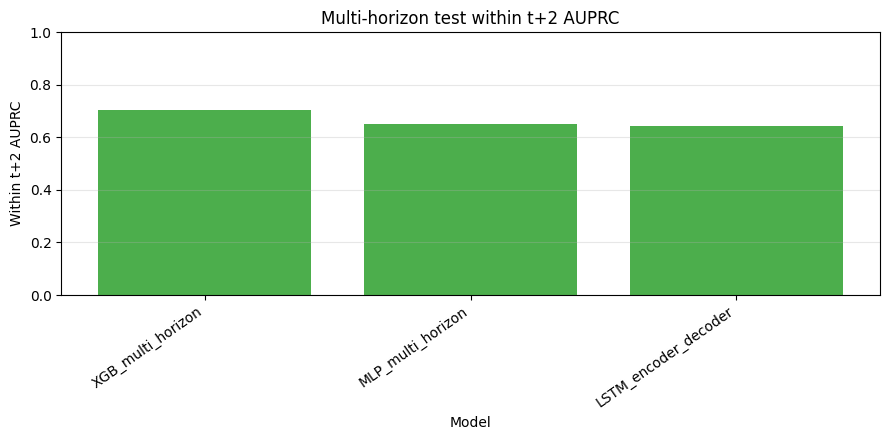

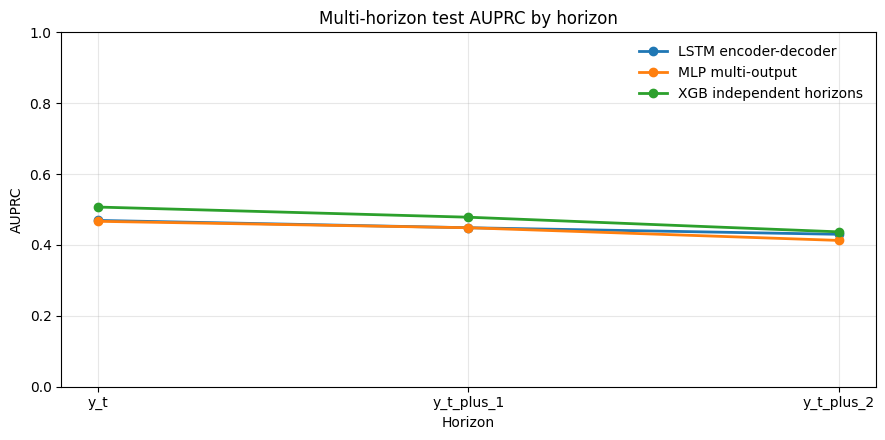

In [27]:
# Multi-horizon 모델별 metric 시각화
all_multi_horizon_metrics = pd.concat(
    [
        xgb_multi_horizon_metrics.assign(model="XGB independent horizons"),
        mlp_multi_horizon_metrics.assign(model="MLP multi-output"),
        multi_horizon_metrics.assign(model="LSTM encoder-decoder"),
    ],
    ignore_index=True,
)

display(multi_summary)
display(all_multi_horizon_metrics)

fig, ax = plt.subplots(figsize=(9, 4.5))
summary_plot = multi_summary.sort_values("within_t_plus_2_auprc", ascending=False)
ax.bar(summary_plot["model"], summary_plot["within_t_plus_2_auprc"], color="tab:green", alpha=0.85)
ax.set_xlabel("Model")
ax.set_ylabel("Within t+2 AUPRC")
ax.set_title("Multi-horizon test within t+2 AUPRC")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "multi_horizon_test_within_t_plus_2_auprc_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for model, model_df in all_multi_horizon_metrics.groupby("model"):
    model_df = model_df.set_index("horizon").loc[HORIZONS]
    ax.plot(HORIZONS, model_df["auprc"], marker="o", linewidth=2, label=model)
ax.set_xlabel("Horizon")
ax.set_ylabel("AUPRC")
ax.set_title("Multi-horizon test AUPRC by horizon")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "multi_horizon_test_horizon_auprc_by_model.png", dpi=200, bbox_inches="tight")
plt.show()


## Previous delirium stratified evaluation

In [28]:
# Within t+2 전체 모델의 층화 평가
within_stratified_rows = []
for model, prob_col in MODEL_PROB_COLUMNS.items():
    no_prior = within_predictions[within_predictions["prev_delirium_group"] == "no_prev_delirium"]
    prior = within_predictions[within_predictions["prev_delirium_group"] == "prev_delirium"]

    add_metric_row(
        within_stratified_rows,
        analysis="delirium_within_t_plus_2_from_no_prev_delirium",
        model=model,
        group="no_prev_delirium",
        target="within_t_plus_2_delirium",
        y_true=no_prior["y_within_t_plus_2_true"],
        y_prob=no_prior[prob_col],
    )
    add_metric_row(
        within_stratified_rows,
        analysis="no_delirium_within_t_plus_2_from_prev_delirium",
        model=model,
        group="prev_delirium",
        target="no_delirium_within_t_plus_2",
        y_true=1 - prior["y_within_t_plus_2_true"].astype(int),
        y_prob=1 - prior[prob_col],
    )

within_stratified_metrics = pd.DataFrame(within_stratified_rows)
within_stratified_metrics.to_csv(MODELING_OUTPUT_DIR / "within_t_plus_2_prev_delirium_stratified_metrics.csv", index=False)
display(within_stratified_metrics.sort_values(["analysis", "auprc"], ascending=[True, False]))


,analysis,model,t_minus_1_group,target,n,positive_rate,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn
10,new_onset_from_no_prior_delirium,Single-output LSTM,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.710377,0.510414,0.632184,0.697383,0.452675,0.827260,220,266,613,128
2,new_onset_from_no_prior_delirium,RF,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.722382,0.473304,0.606322,0.720137,0.461707,0.822078,211,246,633,137
4,new_onset_from_no_prior_delirium,XGB,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.718111,0.463009,0.692529,0.618885,0.418403,0.835637,241,335,544,107
6,new_onset_from_no_prior_delirium,LightGBM,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.709298,0.448393,0.675287,0.656428,0.437616,0.836232,235,302,577,113
8,new_onset_from_no_prior_delirium,MLP,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.693465,0.438997,0.566092,0.742890,0.465721,0.812189,197,226,653,151
0,new_onset_from_no_prior_delirium,LR,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.660825,0.421380,0.629310,0.591581,0.378893,0.801233,219,359,520,129
11,recovery_from_prior_delirium,Single-output LSTM,prior_delirium,no_delirium_within_t_plus_2,363,0.247934,0.717501,0.438471,0.400000,0.846154,0.461538,0.810526,36,42,231,54
9,recovery_from_prior_delirium,MLP,prior_delirium,no_delirium_within_t_plus_2,363,0.247934,0.654579,0.417252,0.188889,0.941392,0.515152,0.778788,17,16,257,73
5,recovery_from_prior_delirium,XGB,prior_delirium,no_delirium_within_t_plus_2,363,0.247934,0.654335,0.407735,0.055556,0.989011,0.625000,0.760563,5,3,270,85
7,recovery_from_prior_delirium,LightGBM,prior_delirium,no_delirium_within_t_plus_2,363,0.247934,0.650041,0.387805,0.077778,0.985348,0.636364,0.764205,7,4,269,83


In [29]:
# Single-output LSTM과 multi-horizon LSTM의 층화 평가
lstm_stratified_rows = []

single_no_prior = within_predictions[within_predictions["prev_delirium_group"] == "no_prev_delirium"]
single_prior = within_predictions[within_predictions["prev_delirium_group"] == "prev_delirium"]
add_metric_row(
    lstm_stratified_rows,
    analysis="delirium_within_t_plus_2_from_no_prev_delirium",
    model="Single-output LSTM",
    group="no_prev_delirium",
    target="within_t_plus_2_delirium",
    y_true=single_no_prior["y_within_t_plus_2_true"],
    y_prob=single_no_prior["lstm_prob"],
)
add_metric_row(
    lstm_stratified_rows,
    analysis="no_delirium_within_t_plus_2_from_prev_delirium",
    model="Single-output LSTM",
    group="prev_delirium",
    target="no_delirium_within_t_plus_2",
    y_true=1 - single_prior["y_within_t_plus_2_true"].astype(int),
    y_prob=1 - single_prior["lstm_prob"],
)

multi_no_prior = multi_predictions[multi_predictions["prev_delirium_group"] == "no_prev_delirium"]
multi_prior = multi_predictions[multi_predictions["prev_delirium_group"] == "prev_delirium"]
add_metric_row(
    lstm_stratified_rows,
    analysis="delirium_within_t_plus_2_from_no_prev_delirium",
    model="Multi-horizon LSTM",
    group="no_prev_delirium",
    target="within_t_plus_2_delirium_from_horizons",
    y_true=multi_no_prior["y_within_t_plus_2_true"],
    y_prob=multi_no_prior["y_within_t_plus_2_prob_from_horizons"],
)
add_metric_row(
    lstm_stratified_rows,
    analysis="no_delirium_within_t_plus_2_from_prev_delirium",
    model="Multi-horizon LSTM",
    group="prev_delirium",
    target="no_delirium_within_t_plus_2_from_horizons",
    y_true=1 - multi_prior["y_within_t_plus_2_true"].astype(int),
    y_prob=1 - multi_prior["y_within_t_plus_2_prob_from_horizons"],
)

lstm_stratified_metrics = pd.DataFrame(lstm_stratified_rows)
lstm_stratified_metrics.to_csv(MODELING_OUTPUT_DIR / "lstm_prev_delirium_stratified_metrics.csv", index=False)
display(lstm_stratified_metrics)


,analysis,model,t_minus_1_group,target,n,positive_rate,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn
0,new_onset_from_no_prior_delirium,Single-output LSTM,no_prior_delirium,within_t_plus_2_delirium,1227,0.283619,0.710377,0.510414,0.632184,0.697383,0.452675,0.827260,220,266,613,128
1,recovery_from_prior_delirium,Single-output LSTM,prior_delirium,no_delirium_within_t_plus_2,363,0.247934,0.717501,0.438471,0.400000,0.846154,0.461538,0.810526,36,42,231,54
2,new_onset_from_no_prior_delirium,Multi-horizon LSTM,no_prior_delirium,within_t_plus_2_delirium_from_horizons,1539,0.241715,0.754598,0.440157,0.712366,0.706941,0.436573,0.885193,265,342,825,107
3,recovery_from_prior_delirium,Multi-horizon LSTM,prior_delirium,no_delirium_within_t_plus_2_from_horizons,405,0.296296,0.723450,0.555750,0.291667,0.908772,0.573770,0.752907,35,26,259,85
4,next_step_new_onset_from_no_prior_delirium,Multi-horizon LSTM,no_prior_delirium,y_t_delirium,1539,0.122157,0.750073,0.254591,0.547872,0.784604,0.261421,0.925764,103,291,1060,85
5,next_step_recovery_from_prior_delirium,Multi-horizon LSTM,prior_delirium,no_y_t_delirium,405,0.523457,0.683009,0.700626,0.339623,0.860104,0.727273,0.542484,72,27,166,140


In [30]:
# 전체 multi-horizon 모델의 층화 평가
multi_model_prediction_sets = [
    ("XGB independent horizons", xgb_multi_predictions),
    ("MLP multi-output", mlp_multi_predictions),
    ("LSTM encoder-decoder", multi_predictions),
]

multi_model_stratified_rows = []
for model, prediction_df in multi_model_prediction_sets:
    no_prior = prediction_df[prediction_df["prev_delirium_group"] == "no_prev_delirium"]
    prior = prediction_df[prediction_df["prev_delirium_group"] == "prev_delirium"]

    add_metric_row(
        multi_model_stratified_rows,
        analysis="delirium_within_t_plus_2_from_no_prev_delirium",
        model=model,
        group="no_prev_delirium",
        target="within_t_plus_2_delirium_from_horizons",
        y_true=no_prior["y_within_t_plus_2_true"],
        y_prob=no_prior["y_within_t_plus_2_prob_from_horizons"],
    )
    add_metric_row(
        multi_model_stratified_rows,
        analysis="no_delirium_within_t_plus_2_from_prev_delirium",
        model=model,
        group="prev_delirium",
        target="no_delirium_within_t_plus_2_from_horizons",
        y_true=1 - prior["y_within_t_plus_2_true"].astype(int),
        y_prob=1 - prior["y_within_t_plus_2_prob_from_horizons"],
    )

multi_model_stratified_metrics = pd.DataFrame(multi_model_stratified_rows)
multi_model_stratified_metrics.to_csv(MODELING_OUTPUT_DIR / "multi_horizon_models_prev_delirium_stratified_metrics.csv", index=False)
display(multi_model_stratified_metrics)


,analysis,model,t_minus_1_group,target,n,positive_rate,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn
0,new_onset_from_no_prior_delirium,XGB independent horizons,no_prior_delirium,within_t_plus_2_delirium_from_horizons,1539,0.241715,0.774587,0.503121,0.962366,0.348757,0.320215,0.966746,358,760,407,14
1,recovery_from_prior_delirium,XGB independent horizons,prior_delirium,no_delirium_within_t_plus_2_from_horizons,405,0.296296,0.715702,0.572102,0.100000,0.996491,0.923077,0.724490,12,1,284,108
2,new_onset_from_no_prior_delirium,MLP multi-output,no_prior_delirium,within_t_plus_2_delirium_from_horizons,1539,0.241715,0.743159,0.431140,0.846774,0.463582,0.334750,0.904682,315,626,541,57
3,recovery_from_prior_delirium,MLP multi-output,prior_delirium,no_delirium_within_t_plus_2_from_horizons,405,0.296296,0.680205,0.549271,0.141667,0.982456,0.772727,0.731070,17,5,280,103
4,new_onset_from_no_prior_delirium,LSTM encoder-decoder,no_prior_delirium,within_t_plus_2_delirium_from_horizons,1539,0.241715,0.754598,0.440157,0.712366,0.706941,0.436573,0.885193,265,342,825,107
5,recovery_from_prior_delirium,LSTM encoder-decoder,prior_delirium,no_delirium_within_t_plus_2_from_horizons,405,0.296296,0.723450,0.555750,0.291667,0.908772,0.573770,0.752907,35,26,259,85


In [31]:
# 전체 multi-horizon 모델의 horizon별 층화 평가
horizon_rows = []
for model, prediction_df in multi_model_prediction_sets:
    for horizon in HORIZONS:
        true_col = f"{horizon}_true"
        mask_col = f"{horizon}_mask"
        prob_col = f"{horizon}_prob"

        no_prior = prediction_df[(prediction_df["prev_delirium_group"] == "no_prev_delirium") & (prediction_df[mask_col] == 1)]
        prior = prediction_df[(prediction_df["prev_delirium_group"] == "prev_delirium") & (prediction_df[mask_col] == 1)]

        add_metric_row(
            horizon_rows,
            analysis="horizon_delirium_within_t_plus_2_from_no_prev_delirium",
            model=model,
            group="no_prev_delirium",
            target=f"{horizon}_delirium",
            y_true=no_prior[true_col],
            y_prob=no_prior[prob_col],
        )
        add_metric_row(
            horizon_rows,
            analysis="horizon_no_delirium_within_t_plus_2_from_prev_delirium",
            model=model,
            group="prev_delirium",
            target=f"no_{horizon}_delirium",
            y_true=1 - prior[true_col].astype(int),
            y_prob=1 - prior[prob_col],
        )

multi_horizon_stratified_metrics = pd.DataFrame(horizon_rows)
multi_horizon_stratified_metrics.to_csv(MODELING_OUTPUT_DIR / "multi_horizon_models_prev_delirium_horizon_metrics.csv", index=False)
display(multi_horizon_stratified_metrics)


,analysis,model,t_minus_1_group,target,n,positive_rate,auroc,auprc,sensitivity,specificity,ppv,npv,tp,fp,tn,fn
0,horizon_new_onset_from_no_prior_delirium,XGB independent horizons,no_prior_delirium,y_t_delirium,1539,0.122157,0.807032,0.306135,0.813830,0.694301,0.270318,0.964029,153,413,938,35
1,horizon_recovery_from_prior_delirium,XGB independent horizons,prior_delirium,no_y_t_delirium,405,0.523457,0.664239,0.704517,0.193396,0.953368,0.820000,0.518310,41,9,184,171
2,horizon_new_onset_from_no_prior_delirium,XGB independent horizons,no_prior_delirium,y_t_plus_1_delirium,1384,0.129335,0.692074,0.257605,0.525140,0.756017,0.242268,0.914659,94,294,911,85
3,horizon_recovery_from_prior_delirium,XGB independent horizons,prior_delirium,no_y_t_plus_1_delirium,383,0.548303,0.646325,0.683096,0.090476,0.971098,0.791667,0.467967,19,5,168,191
4,horizon_new_onset_from_no_prior_delirium,XGB independent horizons,no_prior_delirium,y_t_plus_2_delirium,1227,0.136919,0.669207,0.207267,0.601190,0.648725,0.213531,0.911141,101,372,687,67
5,horizon_recovery_from_prior_delirium,XGB independent horizons,prior_delirium,no_y_t_plus_2_delirium,363,0.556474,0.618750,0.640309,0.103960,0.919255,0.617647,0.449848,21,13,148,181
6,horizon_new_onset_from_no_prior_delirium,MLP multi-output,no_prior_delirium,y_t_delirium,1539,0.122157,0.741043,0.247852,0.473404,0.806810,0.254286,0.916737,89,261,1090,99
7,horizon_recovery_from_prior_delirium,MLP multi-output,prior_delirium,no_y_t_delirium,405,0.523457,0.625049,0.655416,0.207547,0.922280,0.745763,0.514451,44,15,178,168
8,horizon_new_onset_from_no_prior_delirium,MLP multi-output,no_prior_delirium,y_t_plus_1_delirium,1384,0.129335,0.680280,0.227336,0.413408,0.800830,0.235669,0.901869,74,240,965,105
9,horizon_recovery_from_prior_delirium,MLP multi-output,prior_delirium,no_y_t_plus_1_delirium,383,0.548303,0.635714,0.697508,0.200000,0.947977,0.823529,0.493976,42,9,164,168


## Stratified visualizations

In [ ]:
# Within t+2 모델별 층화 AUPRC 시각화
plot_df = within_stratified_metrics.copy()
plot_df["label"] = np.where(
    plot_df["analysis"] == "delirium_within_t_plus_2_from_no_prev_delirium",
    "Delirium within t+2 | previous no delirium",
    "No delirium within t+2 | previous delirium",
)

fig, ax = plt.subplots(figsize=(10, 5))
for idx, label in enumerate(plot_df["label"].unique()):
    subset = plot_df[plot_df["label"] == label].sort_values("model")
    x = np.arange(len(subset)) + (idx - 0.5) * 0.35
    ax.bar(x, subset["auprc"], width=0.35, label=label)
ax.set_xticks(np.arange(len(subset)))
ax.set_xticklabels(subset["model"], rotation=35, ha="right")
ax.set_xlabel("Model")
ax.set_ylabel("AUPRC")
ax.set_title("Within t+2 stratified AUPRC by previous delirium status")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "within_t_plus_2_prev_delirium_stratified_auprc.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# LSTM 모델의 층화 AUPRC와 AUROC 시각화
lstm_plot = lstm_stratified_metrics[lstm_stratified_metrics["analysis"].isin([
    "delirium_within_t_plus_2_from_no_prev_delirium",
    "no_delirium_within_t_plus_2_from_prev_delirium",
])].copy()
lstm_plot["label"] = np.where(
    lstm_plot["analysis"] == "delirium_within_t_plus_2_from_no_prev_delirium",
    "Delirium within t+2 | previous no delirium",
    "No delirium within t+2 | previous delirium",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, metric in zip(axes, ["auprc", "auroc"]):
    pivot = lstm_plot.pivot(index="model", columns="label", values=metric)
    pivot.plot(kind="bar", ax=ax, width=0.75)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"LSTM {metric.upper()} by previous delirium group")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "lstm_prev_delirium_stratified_auprc_auroc.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Multi-horizon 모델의 horizon별 층화 AUPRC 시각화
horizon_plot = multi_horizon_stratified_metrics.copy()
horizon_plot["horizon"] = horizon_plot["target"].str.replace("no_", "", regex=False).str.replace("_delirium", "", regex=False)
horizon_plot["label"] = np.where(
    horizon_plot["analysis"] == "horizon_delirium_within_t_plus_2_from_no_prev_delirium",
    "Delirium within t+2 | previous no delirium",
    "No delirium within t+2 | previous delirium",
)

for label in horizon_plot["label"].unique():
    fig, ax = plt.subplots(figsize=(9, 4.5))
    subset = horizon_plot[horizon_plot["label"] == label]
    for model, model_df in subset.groupby("model"):
        model_df = model_df.set_index("horizon").loc[HORIZONS]
        ax.plot(HORIZONS, model_df["auprc"], marker="o", linewidth=2, label=model)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("AUPRC")
    ax.set_title(f"{label}: horizon-specific AUPRC")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()
    safe_label = label.lower().replace(" ", "_").replace("|", "").replace("-", "minus")
    fig.savefig(FIGURE_DIR / f"multi_horizon_models_prev_delirium_{safe_label}_horizon_auprc.png", dpi=200, bbox_inches="tight")
    plt.show()


## Save augmented prediction tables

In [ ]:
# previous delirium 상태가 결합된 row-level prediction table 저장
within_predictions.to_csv(MODELING_OUTPUT_DIR / "within_t_plus_2_test_predictions_all_models_with_prev_delirium.csv", index=False)
xgb_multi_predictions.to_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_predictions_with_prev_delirium.csv", index=False)
mlp_multi_predictions.to_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_predictions_with_prev_delirium.csv", index=False)
multi_predictions.to_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_predictions_with_prev_delirium.csv", index=False)

print("Saved result analysis tables and figures")
